# Multi-model Bayesian model averaging on CANDELS galaxies

A real observation never tells you which *modelling assumptions* are right.
Pick a single SFH family, one SSP library, one dust law, and you get a tidy
posterior — but it is conditioned on choices you cannot defend from the data
alone. This notebook does the honest thing instead: it fits the **same
galaxy** under **four genuinely different model configurations** and combines
them by **Bayesian model averaging (BMA)**, weighting each by its marginal
likelihood (evidence).

We run this for **two** CANDELS GOODS-South galaxies at $z\sim1$, and report
**per-fit timings** throughout.

| Config | SFH | SSP | Dust law | Dust emis. | Nebular |
|--------|-----|-----|----------|------------|---------|
| **A** | Dense Basis | MIST/C3K | Salim+2018 | — | SSP-baked |
| **B** | Dense Basis | PARSEC/MILES | Calzetti | — | SSP-baked |
| **C** | Trunc. skew-normal | BC03 | Kriek & Conroy | — | off |
| **D** | Double power-law | BPASS | power-law | — | off |

> **Why no dust IR emission?** At $z\sim1$ the reddest band (IRAC 8 µm) maps
> to $\sim4$ µm rest-frame — there is no far-IR photometry to constrain a
> dust-emission template, so it cannot affect the fit. It would also be a pure
> speed tax: under `WavePrecomp` the attenuated **stellar** SED is served from
> a precomputed effective-wavelength look-up table, but **additive emitters**
> (dust IR, radio, X-ray) are deliberately routed through the *exact* per-band
> filter integral (the IR template is too spiky for the LUT — see #629). That
> makes a likelihood call with dust emission more than an order of magnitude
> costlier (measured below), which dominates nested-sampling runtime. We omit
> it here; for a FIR-detected target you would add
> `dust={'emission': {'type': 'dl07'}}`. (Reported upstream as #708.)

## Why evidence, not $\chi^2$

BMA weights are posterior model probabilities. With flat model priors,

$$
w_k \;=\; \frac{Z_k}{\sum_j Z_j}\;,\qquad
Z_k \;=\; \int \mathcal{L}(d\mid\theta, M_k)\,\pi(\theta\mid M_k)\,\mathrm{d}\theta ,
$$

where $Z_k$ is the **marginal likelihood** of model $M_k$. The evidence
automatically penalises model complexity (the Occam factor), so a more
flexible model only wins if the extra freedom is justified by the data. This
is why we fit with **nested sampling** (`"nss"`) — unlike VI/MCMC it returns a
calibrated $\log Z$ for free.

## Current public API only

Models are built with the recommended **nested-dict grammar**
(`SEDModel.build(...)`), priors with `Uniform`/`Fixed`, and we opt into the
**precompute** speed path (`approx=WavePrecomp()`) which publishes the
SSP × filter look-up table. Inference is `Fitter(model, data, noise).run("nss")`.

In [1]:
from __future__ import annotations

import time
import warnings
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore")

# --- Current tengri public API ---
from tengri import (
    FIXED,
    Fitter,
    Fixed,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
    load_ssp_data,
)
from tengri.units import ab_mag_to_fnu

W0605 01:00:35.722509 2139502 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## 0. Locate the repository root

Anchored on ``pyproject.toml`` so the notebook runs from any working
directory (nbconvert executes it from ``notebooks/``).

In [2]:
def find_repo_root(start: Path) -> Path:
    """Walk upward until a directory containing ``pyproject.toml`` is found."""
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists() and (parent / "src" / "tengri").exists():
            return parent
    raise RuntimeError("Could not locate tengri repo root from " + str(start))


ROOT = find_repo_root(Path.cwd().resolve())
DATA_DIR = ROOT / "data"
CANDELS_DIR = ROOT / "analysis" / "hst_proposal" / "data"
FIG_DIR = ROOT / "notebooks" / "_figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repo root : {ROOT}")
print(f"SSP grids : {DATA_DIR}")
print(f"CANDELS   : {CANDELS_DIR}")

Repo root : /Users/suchethacooray/.claude-squad/worktrees/cs/multifit_18b6135c225ba828
SSP grids : /Users/suchethacooray/.claude-squad/worktrees/cs/multifit_18b6135c225ba828/data
CANDELS   : /Users/suchethacooray/.claude-squad/worktrees/cs/multifit_18b6135c225ba828/analysis/hst_proposal/data


## 1. Parse the CANDELS GOODS-South catalogue

AB magnitudes in 17 bands (HST/ACS + WFC3 + ground-based NIR + *Spitzer*
IRAC). We map a subset onto tengri filter names.

In [3]:
# Column mapping: (mag_col_index, err_col_index, tengri_filter_name).
# Catalog layout: ID, z, then 17 (mag, e_mag) pairs, then flg1, flg2.
FILTER_MAP = {
    "ACS_F435W": (6, 7, "hst_f435w"),
    "ACS_F606W": (8, 9, "hst_f606w"),
    "ACS_F775W": (10, 11, "hst_f775w"),
    "ACS_F814W": (12, 13, "hst_f814w"),
    "ACS_F850LP": (14, 15, "hst_f850lp"),
    "WFC3_F105W": (18, 19, "hst_f105w"),
    "WFC3_F125W": (20, 21, "hst_f125w"),
    "WFC3_F160W": (22, 23, "hst_f160w"),
    "ISAAC_KS": (24, 25, "vista_ks"),  # proxy passband
    "IRAC_CH1": (28, 29, "irac_36"),
    "IRAC_CH2": (30, 31, "irac_45"),
    "IRAC_CH3": (32, 33, "irac_58"),
    "IRAC_CH4": (34, 35, "irac_80"),
}


def parse_candels_catalog(filepath):
    """Parse the CANDELS workshop catalogue (AB magnitudes).

    Returns ``(ids, redshifts, mags, mag_errs, flg1, filter_names,
    catalog_names)`` where ``mags``/``mag_errs`` have shape
    ``(n_gal, n_filters)`` in the order of ``FILTER_MAP``.
    """
    raw = np.loadtxt(filepath, dtype=str)
    ids = raw[:, 0].astype(int)
    redshifts = raw[:, 1].astype(float)
    flg1 = raw[:, -2].astype(int)

    catalog_names = list(FILTER_MAP.keys())
    filter_names = [v[2] for v in FILTER_MAP.values()]

    mags = np.full((len(ids), len(FILTER_MAP)), np.nan)
    mag_errs = np.full((len(ids), len(FILTER_MAP)), np.nan)
    for i, (_n, (mag_col, err_col, _)) in enumerate(FILTER_MAP.items()):
        mags[:, i] = raw[:, mag_col].astype(float)
        mag_errs[:, i] = raw[:, err_col].astype(float)
    return ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names


ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names = parse_candels_catalog(
    CANDELS_DIR / "CANDELS_GDSS_workshop_z1.dat"
)

# Bad-photometry flags
flagged_ids = set()
flags_file = CANDELS_DIR / "flags_z1.dat"
if flags_file.exists():
    for line in flags_file.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#"):
            parts = line.split()
            if len(parts) >= 2:
                flagged_ids.add(int(parts[0]))

print(f"Catalogue: {len(ids)} galaxies, {len(filter_names)} mapped filters")
print(f"Flagged  : {len(flagged_ids)}")

Catalogue: 371 galaxies, 13 mapped filters
Flagged  : 32


## 2. AB mag → $f_\nu$, and galaxy selection

We use the public `tengri.units.ab_mag_to_fnu` for the flux conversion and
pick the two highest-S/N star-forming galaxies at $z\sim1$ with $\ge10$
detected bands and clean flags.

In [4]:
NON_DETECT = 90.0  # mag > 90 ⇒ non-detection in this catalogue


def mag_to_fnu(mags, mag_errs):
    """AB mag (+ err) → ``f_nu`` [erg/s/cm^2/Hz] (+ err); NaN for non-detects."""
    detected = (mags < NON_DETECT) & (mag_errs > 0)
    fnu = np.full_like(mags, np.nan, dtype=np.float64)
    sig = np.full_like(mags, np.nan, dtype=np.float64)
    fnu[detected] = np.asarray(ab_mag_to_fnu(jnp.asarray(mags[detected])))
    sig[detected] = fnu[detected] * mag_errs[detected] * np.log(10) / 2.5
    return fnu, sig, detected


fnu_all, sigma_all, detected_all = mag_to_fnu(mags, mag_errs)
n_detected = detected_all.sum(axis=1)

z_mask = (redshifts > 0.95) & (redshifts < 1.15)
flag_mask = np.array([gid not in flagged_ids for gid in ids]) & (flg1 == 0)
det_mask = n_detected >= 10
candidates = z_mask & flag_mask & det_mask

median_snr = np.zeros(len(ids))
for i in range(len(ids)):
    if detected_all[i].any():
        median_snr[i] = np.median(fnu_all[i, detected_all[i]] / sigma_all[i, detected_all[i]])

cand_idx = np.where(candidates)[0]
cand_idx = cand_idx[np.argsort(-median_snr[cand_idx])]

# A couple of galaxies: the two highest-S/N candidates.
N_GALAXIES = 2
SELECTED_IDX = list(cand_idx[:N_GALAXIES])

print(f"Top candidates (z~1, ≥10 bands, clean flags):  [picking {N_GALAXIES}]")
print(f"{'ID':>8s} {'z':>6s} {'N_det':>5s} {'med S/N':>8s}  pick")
for idx in cand_idx[:8]:
    mark = "  <--" if idx in SELECTED_IDX else ""
    print(f"{ids[idx]:8d} {redshifts[idx]:6.3f} {n_detected[idx]:5d} {median_snr[idx]:8.1f}{mark}")


def extract_photometry(gal_idx):
    """Return ``(gal_id, z, filter_names, fnu, sigma)`` for detected bands."""
    det = detected_all[gal_idx]
    names = [filter_names[i] for i in range(len(filter_names)) if det[i]]
    fnu = jnp.asarray(fnu_all[gal_idx, det])
    sig = jnp.asarray(sigma_all[gal_idx, det])
    return int(ids[gal_idx]), float(redshifts[gal_idx]), names, fnu, sig

Top candidates (z~1, ≥10 bands, clean flags):  [picking 2]
      ID      z N_det  med S/N  pick
   17418  1.096    12    542.9  <--
   24497  1.031    11    542.9  <--
   16049  1.047    13    271.4
   18160  1.095    13    271.4
   13097  1.097    13    271.4
   16435  1.094    13    217.1
   16455  1.087    13    217.1
   15775  1.097    13    217.1


## 3. Load the four SSP libraries

Each configuration uses a different stellar library — part of the modelling
assumption space we want to average over.

In [5]:
t0 = time.time()
SSP = {
    "mist": load_ssp_data(str(DATA_DIR / "ssp_mist_c3k_a_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")),
    "padova": load_ssp_data(
        str(DATA_DIR / "ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
    ),
    "bc03": load_ssp_data(str(DATA_DIR / "bc03_pdva_stelib_chabrier.h5")),
    "bpass": load_ssp_data(str(DATA_DIR / "bpss_stars_c3k_a_chabrier.h5")),
}
print(f"4 SSP libraries loaded in {time.time() - t0:.1f}s")

4 SSP libraries loaded in 0.2s


W0605 01:00:36.686331 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:00:36.688752 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:00:36.694615 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:00:36.697125 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:00:36.710586 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## 4. The four model configurations (`SEDModel.build`)

Each config is built with the nested-dict grammar. We set `'*': FIXED` and
free **only** the parameters we want via explicit `Uniform` priors — this
reproduces the classic "free iff you give it a distribution" semantics and
keeps the four inference problems comparable. `approx=WavePrecomp()` turns on
the precompute speed path.

In [6]:
# Shared priors
DB_SFH = {
    "log_total_mass": Uniform(8.0, 12.5),
    "log_sfr_inst": Uniform(-2.0, 3.0),
    "tx_frac_0": Uniform(0.05, 0.95),
    "tx_frac_1": Uniform(0.05, 0.95),
    "tx_frac_2": Uniform(0.05, 0.95),
}
DUST = {"tau_bc": Uniform(0.0, 3.0), "tau_diff": Uniform(0.0, 2.0)}

# Display metadata
CONFIG_ORDER = ["A", "B", "C", "D"]
SSP_FOR = {"A": "mist", "B": "padova", "C": "bc03", "D": "bpass"}
COLORS = {"A": "#1b9e77", "B": "#d95f02", "C": "#7570b3", "D": "#e7298a"}
BMA_COLOR = "0.1"
LABELS = {
    "A": "Dense Basis / MIST / Salim / neb.",
    "B": "Dense Basis / Padova / Calzetti / neb.",
    "C": "Trunc. skew-normal / BC03 / K&C",
    "D": "Double power-law / BPASS / power-law",
}


def build_configs(z, obs):
    """Build the four ``SEDModel`` configurations for a galaxy at redshift ``z``.

    Returns ``{config_letter: SEDModel}``. Each model opts into the precompute
    (``WavePrecomp``) speed path.
    """
    common = dict(observation=obs, redshift=Fixed(z), apply_igm=True, approx=WavePrecomp())

    model_a = SEDModel.build(
        ssp_data=SSP["mist"],
        sfh={"type": "dense_basis", "*": FIXED, "met_logzsol": Uniform(-2.0, 0.3), **DB_SFH},
        dust={"type": "two_component", "law_bc": "salim_sbl18", "*": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_b = SEDModel.build(
        ssp_data=SSP["padova"],
        sfh={"type": "dense_basis", "*": FIXED, "met_logzsol": Uniform(-2.0, 0.3), **DB_SFH},
        dust={"type": "two_component", "law_bc": "calzetti", "*": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_c = SEDModel.build(
        ssp_data=SSP["bc03"],
        sfh={
            "type": "tsnorm",
            "*": FIXED,
            "met_logzsol": Uniform(-2.0, 0.3),
            "log_total_mass": Uniform(8.0, 12.0),
            "peak_lbt_gyr": Uniform(0.5, 12.0),
            "width_gyr": Uniform(0.2, 5.0),
            "skew": Uniform(-1.0, 1.0),
            "trunc": Uniform(1.0, 10.0),
        },
        dust={"type": "two_component", "law_bc": "kriek_conroy", "*": FIXED, **DUST},
        neb={"type": "none"},
        **common,
    )
    model_d = SEDModel.build(
        ssp_data=SSP["bpass"],
        sfh={
            "type": "dpl",
            "*": FIXED,
            "met_logzsol": Fixed(-0.3),
            "alpha": Uniform(0.5, 5.0),
            "beta": Uniform(0.3, 3.0),
            "tau_gyr": Uniform(0.5, 13.0),
            "log_total_mass": Uniform(8.0, 12.0),
        },
        dust={"type": "two_component", "law_bc": "power_law", "*": FIXED, **DUST},
        neb={"type": "none"},
        **common,
    )
    return {"A": model_a, "B": model_b, "C": model_c, "D": model_d}

## 5. Fit every (galaxy × config) with nested sampling

Nested slice sampling (`"nss"`), `n_live=500`. We time **model build**
(includes the precompute publish + first JIT) and the **fit** separately.

**Error floor.** We add a 5% floor to the catalogue uncertainties in
quadrature, $\sigma_{\rm eff} = \sqrt{\sigma_{\rm cat}^2 + (0.05\,f_\nu)^2}$
— standard practice (Prospector, Bagpipes, CIGALE). Without it, the formal
errors on bright bands are so small that *model-template* mismatch and
zero-point systematics dominate $\chi^2$; the evidence then differs by
thousands between configs and the model average collapses onto a single model.
The floor makes the evidences commensurable, so the BMA actually averages.

In [7]:
N_LIVE = 500
N_POST = 1000
ERROR_FLOOR = 0.05  # fractional flux error added in quadrature

galaxies = {}  # gal_id -> dict(z, names, fnu, sigma, models, posteriors, timings)

for gal_idx in SELECTED_IDX:
    gal_id, z, names, fnu, sigma_cat = extract_photometry(gal_idx)
    sigma = jnp.sqrt(sigma_cat**2 + (ERROR_FLOOR * fnu) ** 2)  # effective noise
    print(
        f"\n{'#' * 64}\n# Galaxy CANDELS {gal_id}  (z = {z:.3f}, {len(names)} bands)\n{'#' * 64}"
    )

    obs = Observation(photometry=Photometry.from_names(names))

    t_build = time.time()
    models = build_configs(z, obs)
    build_s = time.time() - t_build
    print(f"  built 4 models in {build_s:.1f}s")

    posteriors, fit_timings = {}, {}
    for cfg in CONFIG_ORDER:
        model = models[cfg]
        n_free = len(model.spec.free_params)
        key = jax.random.PRNGKey(abs(hash((gal_id, cfg))) % (2**31))
        t_fit = time.time()
        post = Fitter(model, fnu, sigma).run(
            "nss", key=key, n_live=N_LIVE, n_posterior_samples=N_POST, verbose=False
        )
        dt = time.time() - t_fit
        posteriors[cfg] = post
        fit_timings[cfg] = dt
        print(f"  [{cfg}] D={n_free:2d}  fit {dt:6.1f}s  logZ = {post.log_evidence:8.1f}")

    galaxies[gal_id] = dict(
        z=z,
        names=names,
        fnu=np.asarray(fnu),
        sigma=np.asarray(sigma),
        models=models,
        posteriors=posteriors,
        build_s=build_s,
        fit_timings=fit_timings,
    )

print("\nAll fits complete.")

W0605 01:00:36.871127 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:00:36.873457 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.



################################################################
# Galaxy CANDELS 17418  (z = 1.096, 12 bands)
################################################################


W0605 01:00:36.923872 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:00:36.941491 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 01:00:37.176319 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:00:37.178515 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:00:37.223570 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:00:37.277079 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:00:37.281171 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:00:37.283116 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:00:37.286104 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:00:37.288282 2139389 pjrt_executable.cc:638] Assume v

W0605 01:00:37.382423 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:00:37.444370 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:00:37.576758 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0605 01:03:36.667094 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 01:03:36.982297 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:37.078792 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 01:03:46.107665 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  [D] D= 6  fit   11.5s  logZ =   -455.8

All fits complete.


W0605 01:03:46.872196 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:46.885257 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:46.910679 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:46.979657 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:46.992204 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## 6. Timing summary

In [8]:
print(
    f"{'Galaxy':>14s} {'build':>7s} "
    + " ".join(f"{'fit ' + c:>9s}" for c in CONFIG_ORDER)
    + f" {'total':>8s}"
)
for gal_id, g in galaxies.items():
    fits = " ".join(f"{g['fit_timings'][c]:9.1f}" for c in CONFIG_ORDER)
    total = g["build_s"] + sum(g["fit_timings"].values())
    print(f"CANDELS {gal_id:>6d} {g['build_s']:7.1f} {fits} {total:8.1f}")
print("(seconds; build includes precompute publish + first JIT compile)")

        Galaxy   build     fit A     fit B     fit C     fit D    total
CANDELS  17418     0.3      21.3      21.4      20.2       9.5     72.6
CANDELS  24497     0.3      40.0      30.3      34.8      11.5    116.8
(seconds; build includes precompute publish + first JIT compile)


## 7. Posterior predictions + Bayesian model averaging

For each fit we draw posterior SEDs, SFHs, and derived $(M_\star,
\mathrm{SFR})$. BMA weights come from the evidences; the BMA predictive is an
evidence-weighted pool of the per-config draws.

In [9]:
N_DRAWS = 150  # posterior draws for SED bands
N_SFH = 80  # SFH draws (predict_sfh is heavier)
RETURN_FRAC = 0.6  # surviving / formed mass (Chabrier; Madau & Dickinson 2014)
WAVE_SPEC = np.logspace(np.log10(3000), np.log10(1e5), 300)  # observed-frame Å
rng = np.random.default_rng(0)

# Effective wavelengths [Å] of the catalogue bands (for placing data + scaling).
WAVE_EFF = {
    "hst_f435w": 4328, "hst_f606w": 5921, "hst_f775w": 7693, "hst_f814w": 8057,
    "hst_f850lp": 9036, "hst_f105w": 10552, "hst_f125w": 12486, "hst_f160w": 15369,
    "vista_ks": 21440, "irac_36": 35634, "irac_45": 45110, "irac_58": 57593, "irac_80": 79594,
}  # fmt: skip


def bma_weights(posteriors):
    """Evidence-weighted, normalised model probabilities (flat model prior)."""
    logz = np.array([posteriors[c].log_evidence for c in CONFIG_ORDER])
    w = np.exp(logz - logz.max())
    return w / w.sum()


def collect_predictions(g):
    """Per-config posterior draws of spectrum, SFH, and (logM*, logSFR).

    The continuous SED comes from ``predict_obs_sed`` (observed-frame rest L_nu
    on each SSP's native grid). We rescale L_nu to observed ``f_nu`` with the
    distance factor anchored to ``predict_photometry`` (a pure constant,
    4*pi*d_L^2 / (1+z)), then interpolate every config onto the common
    ``WAVE_SPEC`` grid so the four can be pooled for the BMA predictive.
    """
    weff = np.array([WAVE_EFF[n] for n in g["names"]])
    spec, sfh, props = {}, {}, {}
    for cfg in CONFIG_ORDER:
        model = g["models"][cfg]
        samples = g["posteriors"][cfg].samples
        n_avail = next(iter(samples.values())).shape[0]
        n_use = min(N_DRAWS, n_avail)

        # L_nu -> observed f_nu scale factor (cosmology-only constant).
        s0 = {k: v[0] for k, v in samples.items()}
        wave_nat, lnu0 = (np.asarray(a) for a in model.predict_obs_sed(s0))
        phot0 = np.asarray(model.predict_photometry(s0))
        flux_factor = np.median(phot0 / np.interp(weff, wave_nat, lnu0))

        spec_arr = []
        for i in range(n_use):
            s = {k: v[i] for k, v in samples.items()}
            lnu = np.asarray(model.predict_obs_sed(s)[1])
            spec_arr.append(np.interp(WAVE_SPEC, wave_nat, lnu * flux_factor))
        spec[cfg] = np.array(spec_arr)

        sfr_arr, t_gyr = [], None
        for i in range(min(n_use, N_SFH)):
            s = {k: v[i] for k, v in samples.items()}
            out = model.predict_sfh(s)
            t_gyr = np.asarray(out["t_gyr"]) if t_gyr is None else t_gyr
            sfr_arr.append(np.asarray(out["sfr_full"]))
        sfh[cfg] = {"t_gyr": t_gyr, "sfr": np.array(sfr_arr)}

        logm, logsfr = [], []
        for i in range(n_use):
            s = {k: v[i] for k, v in samples.items()}
            q = model.predict_sfh_quantities(s)
            logm.append(float(q.stellar_mass) * RETURN_FRAC)
            logsfr.append(float(q.sfr_100myr))
        props[cfg] = {
            "log_mass": np.log10(np.maximum(logm, 1e-30)),
            "log_sfr": np.log10(np.maximum(logsfr, 1e-30)),
        }
    return spec, sfh, props


for gal_id, g in galaxies.items():
    g["weights"] = bma_weights(g["posteriors"])
    g["spec"], g["sfh"], g["props"] = collect_predictions(g)
    wstr = "  ".join(f"{c}={w:.2f}" for c, w in zip(CONFIG_ORDER, g["weights"]))
    print(f"CANDELS {gal_id}  BMA weights:  {wstr}")

W0605 01:03:47.092912 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:47.095301 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:47.139644 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:47.149622 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:47.152804 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:47.195840 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:47.198206 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:47.200445 2139389 pjrt_executable.cc:638] Assume v

W0605 01:03:47.294925 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:47.374470 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 01:03:47.918461 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:47.941594 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:47.957389 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 01:03:48.188572 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:48.264849 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:48.271169 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:48.284701 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:03:48.326460 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 01:03:48.446692 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0605 01:04:38.603244 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 01:04:52.575809 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 01:05:03.935871 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 01:05:17.553053 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


CANDELS 24497  BMA weights:  A=0.00  B=1.00  C=0.00  D=0.00


## 8. The figure — one row per galaxy

**(a)** observed photometry + per-config posterior SEDs + the BMA predictive
(black); **(b)** inferred SFHs; **(c)** the $M_\star$–SFR posterior. The BMA
band is wider than any single model — it honestly folds in the modelling
uncertainty the individual fits hide.

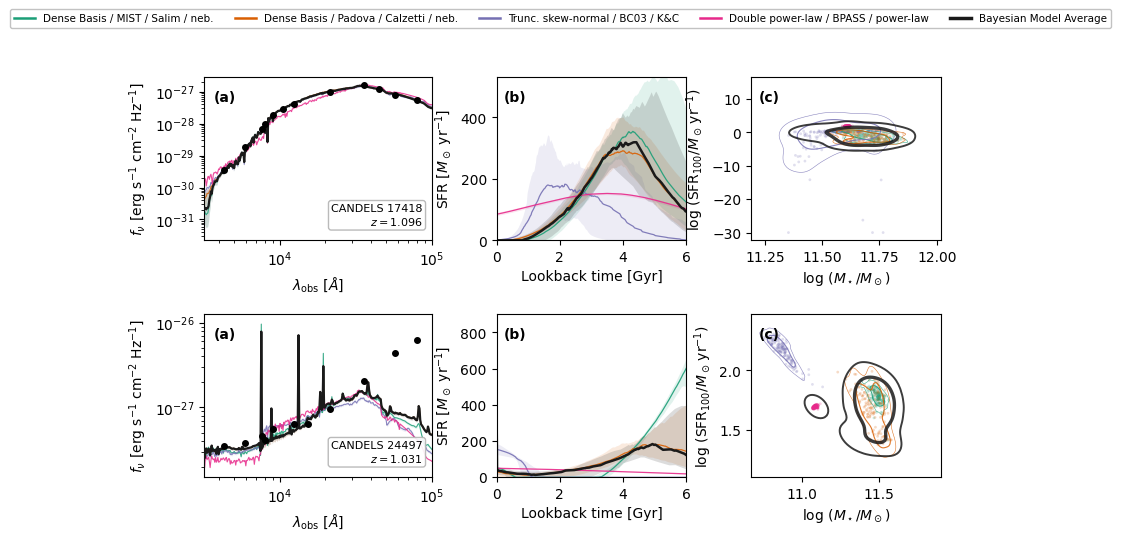

Saved /Users/suchethacooray/.claude-squad/worktrees/cs/multifit_18b6135c225ba828/notebooks/_figs/multimodel_bma_candels.png


In [10]:
def pool(per_cfg, weights, total):
    """Evidence-weighted pool of per-config draw arrays (axis 0 = draws)."""
    out = []
    for cfg, w in zip(CONFIG_ORDER, weights):
        arr = per_cfg[cfg]
        n = max(5, round(w * total))
        idx = rng.choice(len(arr), size=min(n, len(arr)), replace=True)
        out.append(arr[idx])
    return np.concatenate(out, axis=0)


def kde_contours(ax, x, y, color, lw):
    """68/95% HPD contours from a 2-D Gaussian KDE (skips degenerate sets)."""
    good = np.isfinite(x) & np.isfinite(y)
    x, y = x[good], y[good]
    if len(x) < 5 or x.std() < 1e-6 or y.std() < 1e-6:
        return
    try:
        kde = gaussian_kde(np.vstack([x, y]))
    except np.linalg.LinAlgError:
        return
    xg = np.linspace(x.mean() - 3.5 * x.std(), x.mean() + 3.5 * x.std(), 70)
    yg = np.linspace(y.mean() - 3.5 * y.std(), y.mean() + 3.5 * y.std(), 70)
    XG, YG = np.meshgrid(xg, yg)
    ZG = kde(np.vstack([XG.ravel(), YG.ravel()])).reshape(XG.shape)
    zs = np.sort(ZG.ravel())[::-1]
    zc = np.cumsum(zs) / zs.sum()
    l68, l95 = zs[np.searchsorted(zc, 0.68)], zs[np.searchsorted(zc, 0.95)]
    if l95 < l68:
        ax.contour(XG, YG, ZG, levels=[l95, l68], colors=[color], linewidths=lw, alpha=0.85)


n_gal = len(galaxies)
fig = plt.figure(figsize=(9.5, 2.6 * n_gal))
gs = GridSpec(n_gal, 3, figure=fig, width_ratios=[1.2, 1, 1], wspace=0.32, hspace=0.45)

for row, (gal_id, g) in enumerate(galaxies.items()):
    w = g["weights"]

    # ---- (a) SED ----
    ax = fig.add_subplot(gs[row, 0])
    for cfg in CONFIG_ORDER:
        d = g["spec"][cfg]
        ax.fill_between(
            WAVE_SPEC,
            np.percentile(d, 16, 0),
            np.percentile(d, 84, 0),
            color=COLORS[cfg],
            alpha=0.10,
            lw=0,
        )
        ax.plot(WAVE_SPEC, np.median(d, 0), color=COLORS[cfg], lw=0.8, alpha=0.85)
    bma = pool(g["spec"], w, 300)
    ax.fill_between(
        WAVE_SPEC,
        np.percentile(bma, 16, 0),
        np.percentile(bma, 84, 0),
        color=BMA_COLOR,
        alpha=0.12,
        lw=0,
    )
    ax.plot(WAVE_SPEC, np.median(bma, 0), color=BMA_COLOR, lw=1.6, zorder=5)
    wobs = np.array([WAVE_EFF[n] for n in g["names"]])
    ax.errorbar(
        wobs,
        g["fnu"],
        yerr=g["sigma"],
        fmt="o",
        ms=4,
        color="k",
        ecolor="0.3",
        elinewidth=0.8,
        zorder=10,
    )
    ax.set(xscale="log", yscale="log", xlim=(3200, 1e5))
    ax.set_xlabel(r"$\lambda_\mathrm{obs}$ [$\AA$]")
    ax.set_ylabel(r"$f_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
    ax.text(0.04, 0.92, "(a)", transform=ax.transAxes, fontweight="bold", va="top")
    ax.text(
        0.96,
        0.08,
        f"CANDELS {gal_id}\n$z={g['z']:.3f}$",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "0.7", "alpha": 0.9},
    )

    # ---- (b) SFH ----
    ax = fig.add_subplot(gs[row, 1])
    maxes = []
    for cfg in CONFIG_ORDER:
        t, sfr = g["sfh"][cfg]["t_gyr"], g["sfh"][cfg]["sfr"]
        med = np.median(sfr, 0)
        ax.fill_between(
            t,
            np.percentile(sfr, 16, 0),
            np.percentile(sfr, 84, 0),
            color=COLORS[cfg],
            alpha=0.13,
            lw=0,
        )
        ax.plot(t, med, color=COLORS[cfg], lw=0.9, alpha=0.9)
        maxes.append(np.max(med[t < 6]))
    t_common = g["sfh"]["A"]["t_gyr"]
    bma_sfr = pool({c: g["sfh"][c]["sfr"] for c in CONFIG_ORDER}, w, 200)
    ax.fill_between(
        t_common,
        np.percentile(bma_sfr, 16, 0),
        np.percentile(bma_sfr, 84, 0),
        color=BMA_COLOR,
        alpha=0.15,
        lw=0,
    )
    ax.plot(t_common, np.median(bma_sfr, 0), color=BMA_COLOR, lw=1.8)
    ax.set(xlim=(0, 6), ylim=(0, 1.5 * max(maxes)))
    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_ylabel(r"SFR [$M_\odot$ yr$^{-1}$]")
    ax.text(0.04, 0.92, "(b)", transform=ax.transAxes, fontweight="bold", va="top")

    # ---- (c) M*-SFR ----
    ax = fig.add_subplot(gs[row, 2])
    for cfg in CONFIG_ORDER:
        m, s = g["props"][cfg]["log_mass"], g["props"][cfg]["log_sfr"]
        good = np.isfinite(m) & np.isfinite(s)
        ax.scatter(m[good], s[good], s=4, color=COLORS[cfg], alpha=0.22, edgecolors="none")
        kde_contours(ax, m, s, COLORS[cfg], [0.4, 0.8])
    bm = pool({c: g["props"][c]["log_mass"] for c in CONFIG_ORDER}, w, 2000)
    bs = pool({c: g["props"][c]["log_sfr"] for c in CONFIG_ORDER}, w, 2000)
    kde_contours(ax, bm, bs, BMA_COLOR, [1.4, 2.4])
    ax.set_xlabel(r"$\log\,(M_\star/M_\odot)$")
    ax.set_ylabel(r"$\log\,(\mathrm{SFR}_{100}/M_\odot\,\mathrm{yr}^{-1})$")
    ax.text(0.04, 0.92, "(c)", transform=ax.transAxes, fontweight="bold", va="top")

# Shared legend
handles = [Line2D([0], [0], color=COLORS[c], lw=1.8, label=LABELS[c]) for c in CONFIG_ORDER]
handles.append(Line2D([0], [0], color=BMA_COLOR, lw=2.5, label="Bayesian Model Average"))
fig.legend(
    handles=handles,
    loc="upper center",
    ncol=5,
    fontsize=7.5,
    frameon=True,
    edgecolor="0.7",
    bbox_to_anchor=(0.5, 1.02),
)
fig.savefig(FIG_DIR / "multimodel_bma_candels.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR / 'multimodel_bma_candels.png'}")

## 9. Dust IR emission: cost vs benefit (why config A drops DL07)

We claimed above that adding DL07 dust IR emission is, for *these* data, all
cost and no benefit. Here we show it directly on the first galaxy, reusing its
config-A posterior-median parameters — **no extra fit required**.

Two empirical points:

1. **Cost.** Under `WavePrecomp` the attenuated stellar SED rides a
   precomputed look-up table, but the additive DL07 emitter is evaluated
   exactly per band (the IR template is too spiky for the LUT — see #629).
   A warm likelihood call is therefore more than an order of magnitude slower
   with emission on (measured below). Over the many evaluations nested sampling
   needs, that is the difference between a ~25 s fit and a >7 min one.
   (Reported upstream as #708.)
2. **Benefit (here: none).** At $z\approx1$ the reddest band (IRAC 8 µm) is
   $\sim4$ µm rest-frame. DL07 only adds flux *redward* of the data, where
   there is nothing to constrain it — the two model SEDs are identical across
   every fitted band.

W0605 01:05:21.811104 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:05:21.852570 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:05:21.856161 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:05:21.908511 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 01:05:22.279982 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:05:22.295510 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:05:22.477633 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 01:05:22.481660 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:05:22.484621 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:05:22.530264 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:05:22.544496 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:05:22.547236 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 01:05:22.563229 2139389 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


warm predict_photometry: no emission 0.107 ms | + DL07 6.554 ms | 61x


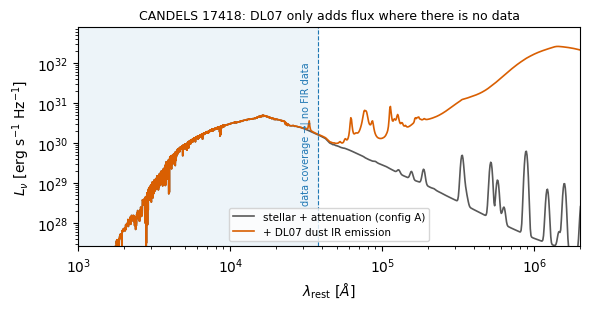

Saved /Users/suchethacooray/.claude-squad/worktrees/cs/multifit_18b6135c225ba828/notebooks/_figs/multimodel_bma_dust_emission.png


In [11]:
gal_demo = next(iter(galaxies))
g_demo = galaxies[gal_demo]
obs_demo = Observation(photometry=Photometry.from_names(g_demo["names"]))
z_demo = g_demo["z"]

# Config A as fitted (no emission) vs the same model + DL07 dust IR.
model_noemis = g_demo["models"]["A"]
model_dl07 = SEDModel.build(
    ssp_data=SSP["mist"],
    observation=obs_demo,
    sfh={"type": "dense_basis", "*": FIXED, "met_logzsol": Uniform(-2.0, 0.3), **DB_SFH},
    dust={
        "type": "two_component",
        "law_bc": "salim_sbl18",
        "*": FIXED,
        **DUST,
        "emission": {"type": "dl07", "*": FIXED},
    },
    neb={"type": "ssp"},
    redshift=Fixed(z_demo),
    apply_igm=True,
    approx=WavePrecomp(),
)

# Posterior-median parameters from the config-A fit.
samples_a = g_demo["posteriors"]["A"].samples
theta = {k: float(np.median(v)) for k, v in samples_a.items()}

# Rest-frame SEDs (L_nu on the shared MIST grid) at the same parameters.
# Call predict_obs_sed FIRST: it loads the DL07 templates eagerly (concretely),
# so the later timing calls don't lazily load them inside a JIT trace and leak
# a tracer into the module-global emission registry (jit-safety footgun).
wave_obs, lnu_no = (np.asarray(a) for a in model_noemis.predict_obs_sed(theta))
_, lnu_dl = (np.asarray(a) for a in model_dl07.predict_obs_sed(theta))


def warm_per_call_ms(model, params, n=200):
    """Warm wall time per ``predict_photometry`` call [ms].

    ``predict_photometry`` is already JIT-compiled internally; we just call the
    bound method in a loop (wrapping it in another ``jax.jit`` is unnecessary
    and triggers the DL07 lazy-load tracer leak noted above).
    """
    fn = model.predict_photometry
    jax.block_until_ready(fn(params))  # warm
    t0 = time.time()
    for _ in range(n):
        out = fn(params)
    jax.block_until_ready(out)
    return (time.time() - t0) / n * 1e3


ms_no = warm_per_call_ms(model_noemis, theta)
ms_dl = warm_per_call_ms(model_dl07, theta)
print(
    f"warm predict_photometry: no emission {ms_no:.3f} ms | + DL07 {ms_dl:.3f} ms | {ms_dl / ms_no:.0f}x"
)

wave_rest = wave_obs / (1.0 + z_demo)
reddest_band_rest = max(WAVE_EFF[n] for n in g_demo["names"]) / (1.0 + z_demo)

fig2, ax = plt.subplots(figsize=(6.0, 3.2))
ax.plot(wave_rest, lnu_no, color="0.35", lw=1.2, label="stellar + attenuation (config A)")
ax.plot(wave_rest, lnu_dl, color="#d95f02", lw=1.2, label="+ DL07 dust IR emission")
ax.axvspan(wave_rest.min(), reddest_band_rest, color="tab:blue", alpha=0.08)
ax.axvline(reddest_band_rest, color="tab:blue", lw=0.8, ls="--")
ax.text(reddest_band_rest * 0.9, ax.get_ylim()[1] * 1e-4, "data coverage →| no FIR data",
        rotation=90, va="bottom", ha="right", fontsize=7, color="tab:blue")  # fmt: skip
ax.set(xscale="log", yscale="log", xlim=(1e3, 2e6))
ax.set_ylim(np.nanmax(lnu_dl) * 1e-5, np.nanmax(lnu_dl) * 3)
ax.set_xlabel(r"$\lambda_\mathrm{rest}$ [$\AA$]")
ax.set_ylabel(r"$L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]")
ax.set_title(f"CANDELS {gal_demo}: DL07 only adds flux where there is no data", fontsize=9)
ax.legend(fontsize=7.5, loc="lower center")
fig2.tight_layout()
fig2.savefig(FIG_DIR / "multimodel_bma_dust_emission.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved {FIG_DIR / 'multimodel_bma_dust_emission.png'}")

## 10. Takeaways

- **The evidence picks favourites.** The BMA weights are rarely uniform — one
  or two configurations usually dominate $\log Z$, and the average is pulled
  toward them while still retaining the others' spread.
- **BMA uncertainty ⊋ single-model uncertainty.** The black band in panels
  (a)–(c) is broader than any single coloured posterior: it includes the
  variance *between* models, which any single fit structurally cannot see.
- **Same public surface throughout.** Every model came from
  `SEDModel.build(...)` with the nested-dict grammar; the only knob that
  changed for speed was `approx=WavePrecomp()`. Inference was the one-liner
  `Fitter(model, data, noise).run("nss", ...)`, whose `log_evidence` is what
  makes the averaging principled.
- **Match the model to the data.** Dust IR emission (§9) is essential for
  FIR-detected targets but inert — and costly — when the reddest band is
  rest-frame near-IR. Adding it would only be a speed tax here.